In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tfgans import utils
from tfgans.cycleGAN import models 

2026-09-17 13:09:10.066034: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-17 13:09:10.066063: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-17 13:09:10.066716: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-17 13:09:10.070715: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-17 13:09:10.785131: W tensorflow/compiler/tf2

In [2]:
ct_dir = "/home/sagar/projects/GHOST/data/processed/lung/ct/"
histo_dir = "/home/sagar/projects/GHOST/data/processed/lung/histo/"

In [3]:
ct_data = utils.load_images_in_shape(ct_dir, color_mode="rgb") 
histo_data = utils.load_images_in_shape(histo_dir, color_mode="rgb")

Found 896 files in the directory


100%|██████████| 896/896 [00:00<00:00, 1270.25it/s]


Loaded (896, 256, 256, 3) images
Found 896 files in the directory


100%|██████████| 896/896 [00:00<00:00, 1306.63it/s]


Loaded (896, 256, 256, 3) images


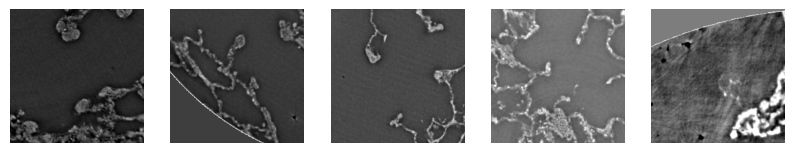

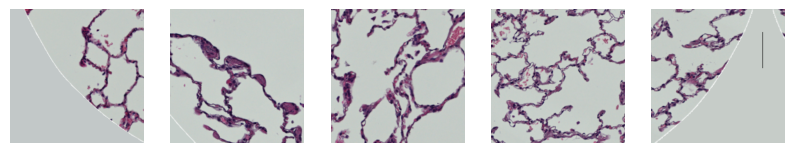

In [4]:
idxA = np.random.randint(0, len(ct_data), 5)
idxB = np.random.randint(0, len(histo_data), 5)

plt.figure(figsize=(10,5))
for i, idx in enumerate(idxA):
    plt.subplot(1, 5, 1 + i)
    plt.axis('off')
    plt.imshow(ct_data[idx].astype('uint8'))
plt.show()
plt.figure(figsize=(10,5))
for i, idx in enumerate(idxB):
    plt.subplot(1, 5, 1 + i)
    plt.axis('off')
    plt.imshow(histo_data[idx].astype('uint8'))
plt.show()

In [5]:
ct_data = utils.scale_data(ct_data)
histo_data = utils.scale_data(histo_data)

In [ ]:
# input shape
image_shape = ct_data.shape[1:]

# generator model 
genCT2Histo = models.build_generator(input_shape=image_shape)
genHisto2CT = models.build_generator(input_shape=image_shape)

# discriminator model
disCT = models.build_discriminator(input_shape=image_shape)
disHisto = models.build_discriminator(input_shape=image_shape)

# cycleGAN
cycleGAN_CT2Histo = models.build_cycleGAN(genCT2Histo, disHisto, genHisto2CT, input_shape=image_shape)
cycleGAN_Histo2CT = models.build_cycleGAN(genHisto2CT, disCT, genCT2Histo, input_shape=image_shape)

output_folder = "../training_output/"
name = "cycleGAN"
output_dir = os.path.join(output_folder, name)

# Training 
models.train_cycleGAN(disCT, disHisto, genCT2Histo, genHisto2CT, cycleGAN_CT2Histo, cycleGAN_Histo2CT, ct_data, histo_data,
                      batch_size=1, epochs=2, summary_interval=1, nameA2B='CT2Histo', nameB2A='Histo2CT', name=output_dir)